In [8]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
import numpy as np

types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']

red_dims = {}
orig_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['cosine']= {}
    distance_matrix = pdist(X, metric="cosine")
    for i in range(len(link)):
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        c = cophenet(linked, distance_matrix)[0] 
        red_dims[type_of_matrix]['cosine'][link[i]] = c
    

In [9]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['euclidean']= {}
    distance_matrix = pdist(X, metric="euclidean")
    for i in range(len(link)):
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        c = cophenet(linked, distance_matrix)[0] 
        red_dims[type_of_matrix]['euclidean'][link[i]] = c

In [10]:
red_dims

{'precision': {'cosine': {'single': 0.5151174037723967,
   'average': 0.6758637167575382,
   'complete': 0.5307430782537296},
  'euclidean': {'single': 0.9735514925468547,
   'average': 0.9843207823307031,
   'ward': 0.8540152434294935,
   'complete': 0.9750739099603897,
   'centroid': 0.98404075906562}},
 'coverage': {'cosine': {'single': 0.7540064589318288,
   'average': 0.8472457160829538,
   'complete': 0.6199574877959358},
  'euclidean': {'single': 0.836693164610612,
   'average': 0.891154011514154,
   'ward': 0.7289174023159487,
   'complete': 0.7824231021447996,
   'centroid': 0.884887032084074}},
 'PMI': {'cosine': {'single': 0.3222325699675076,
   'average': 0.6087154537284233,
   'complete': 0.5254588650968137},
  'euclidean': {'single': 0.8903531817555024,
   'average': 0.9100796971252029,
   'ward': 0.4795882513569264,
   'complete': 0.31508175785876724,
   'centroid': 0.9008068062522459}},
 'tf-idf': {'cosine': {'single': 0.6971915502557023,
   'average': 0.802959226760902

In [12]:
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['cosine']= {}
    distance_matrix = pdist(X, metric="cosine")
    for i in range(len(link)):
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        c = cophenet(linked, distance_matrix)[0] 
        orig_dims[type_of_matrix]['cosine'][link[i]] = c

In [13]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['euclidean']= {}
    distance_matrix = pdist(X, metric="euclidean")
    for i in range(len(link)):
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        c = cophenet(linked, distance_matrix)[0] 
        orig_dims[type_of_matrix]['euclidean'][link[i]] = c

In [14]:
orig_dims

{'precision': {'cosine': {'single': 0.6087701578443473,
   'average': 0.8015883524912342,
   'complete': 0.6726812497783439},
  'euclidean': {'single': 0.992666276120449,
   'average': 0.9947055458787938,
   'ward': 0.9862260681558161,
   'complete': 0.9885350072753879,
   'centroid': 0.9944814924918514}},
 'coverage': {'cosine': {'single': 0.7278247572033497,
   'average': 0.8614012233078109,
   'complete': 0.7368747849229453},
  'euclidean': {'single': 0.8098432526404217,
   'average': 0.8785082599011443,
   'ward': 0.6637747546384566,
   'complete': 0.6755493708812973,
   'centroid': 0.882956869236235}},
 'PMI': {'cosine': {'single': 0.39833392716704336,
   'average': 0.5741586587281653,
   'complete': 0.5004322717512218},
  'euclidean': {'single': 0.9108464557243438,
   'average': 0.912777224464912,
   'ward': 0.6042502463698987,
   'complete': 0.8454673237459217,
   'centroid': 0.9166675829114543}},
 'tf-idf': {'cosine': {'single': 0.7831190402138191,
   'average': 0.7584828234840

In [15]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

connected to port: 57276


Number of matches after filtering: 11701


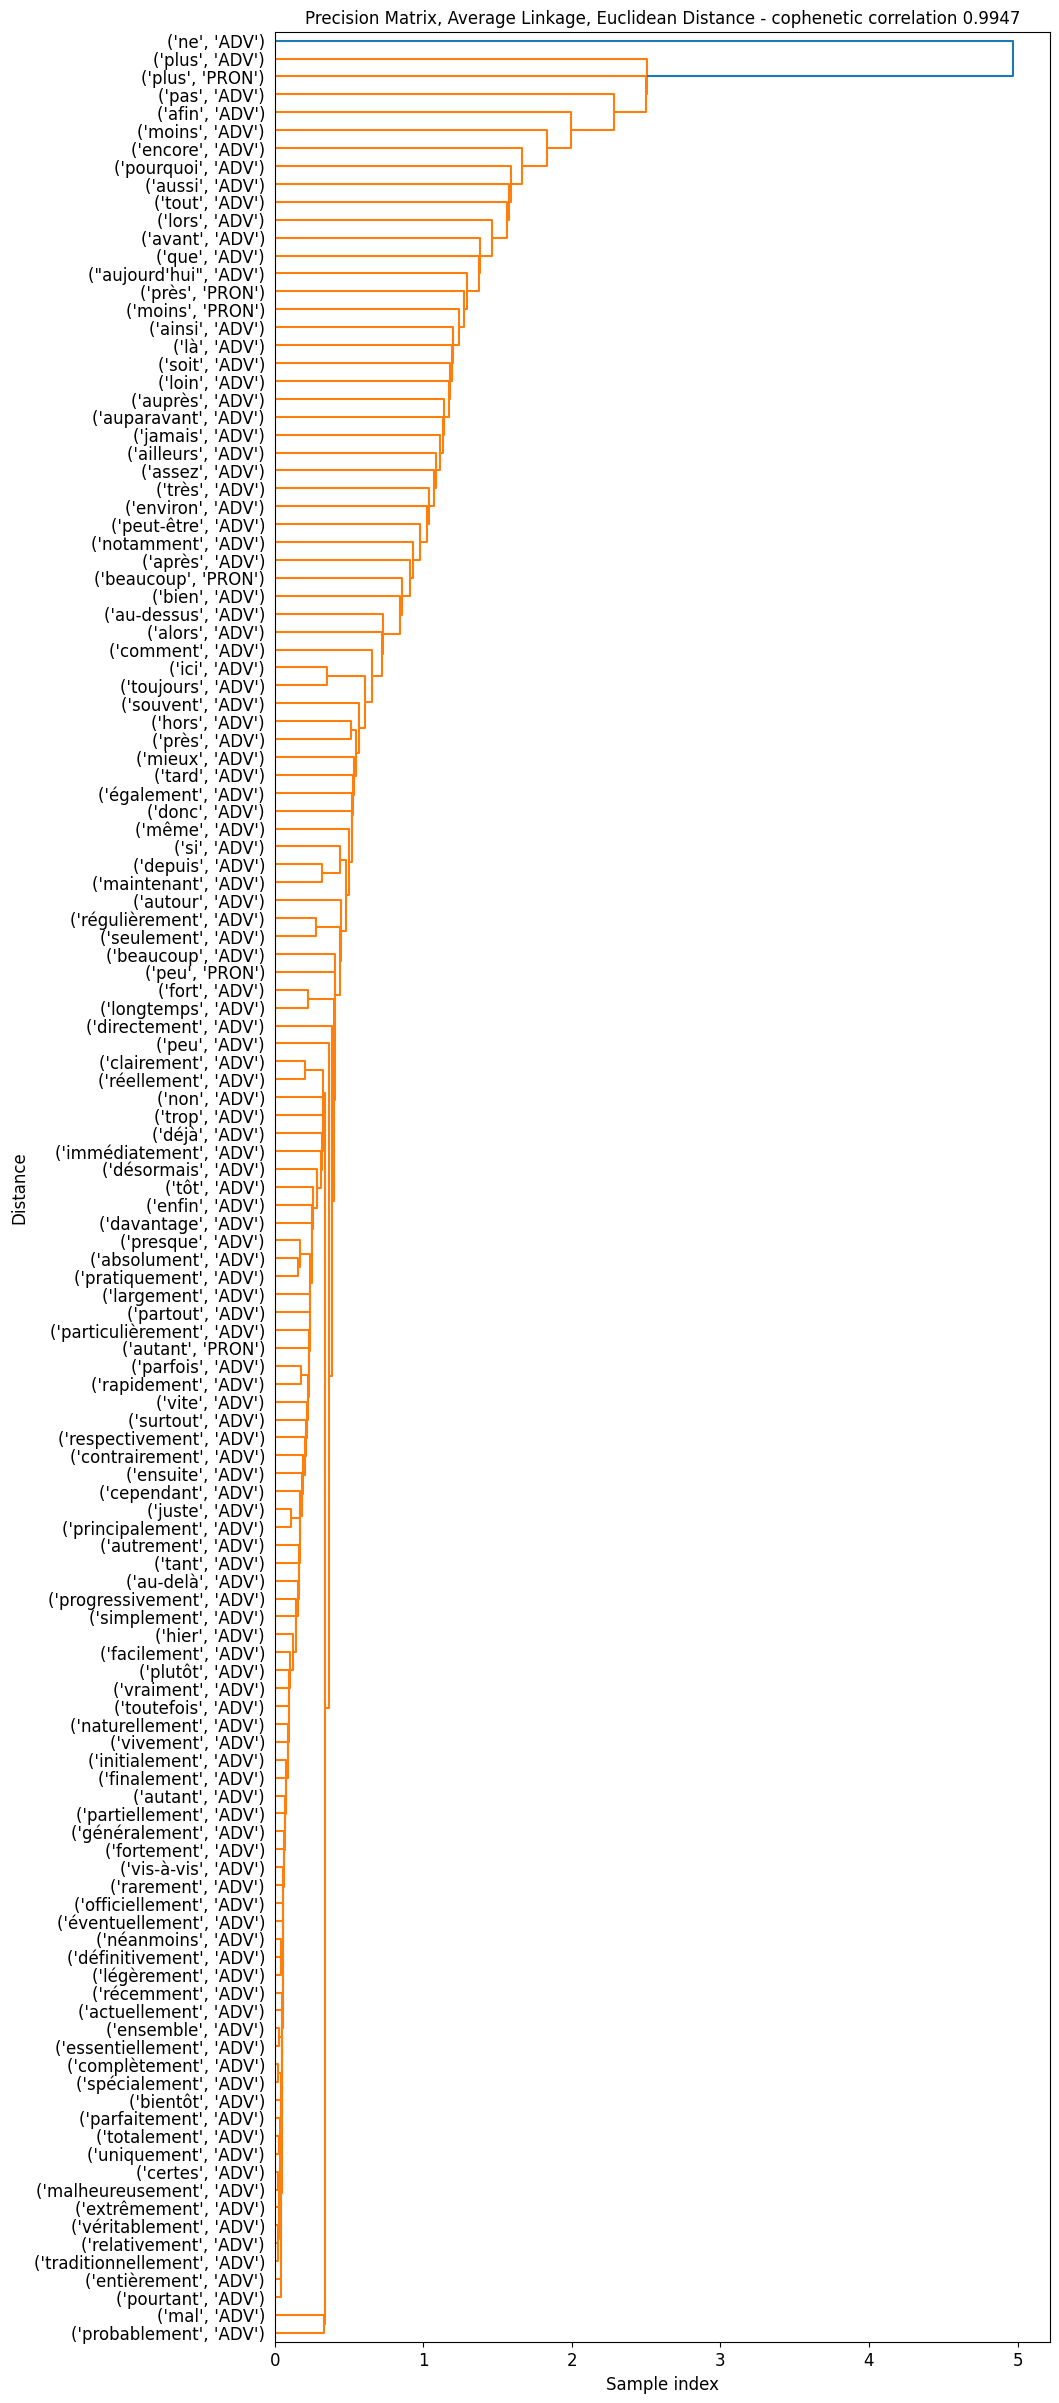

In [20]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

with open(f"precision_orig_dims.npy", 'rb') as f:
        X = np.load(f)
distance_matrix = pdist(X, metric="euclidean")
linked = linkage(
            distance_matrix, method="average", optimal_ordering=False
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Precision Matrix, Average Linkage, Euclidean Distance - cophenetic correlation 0.9947', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

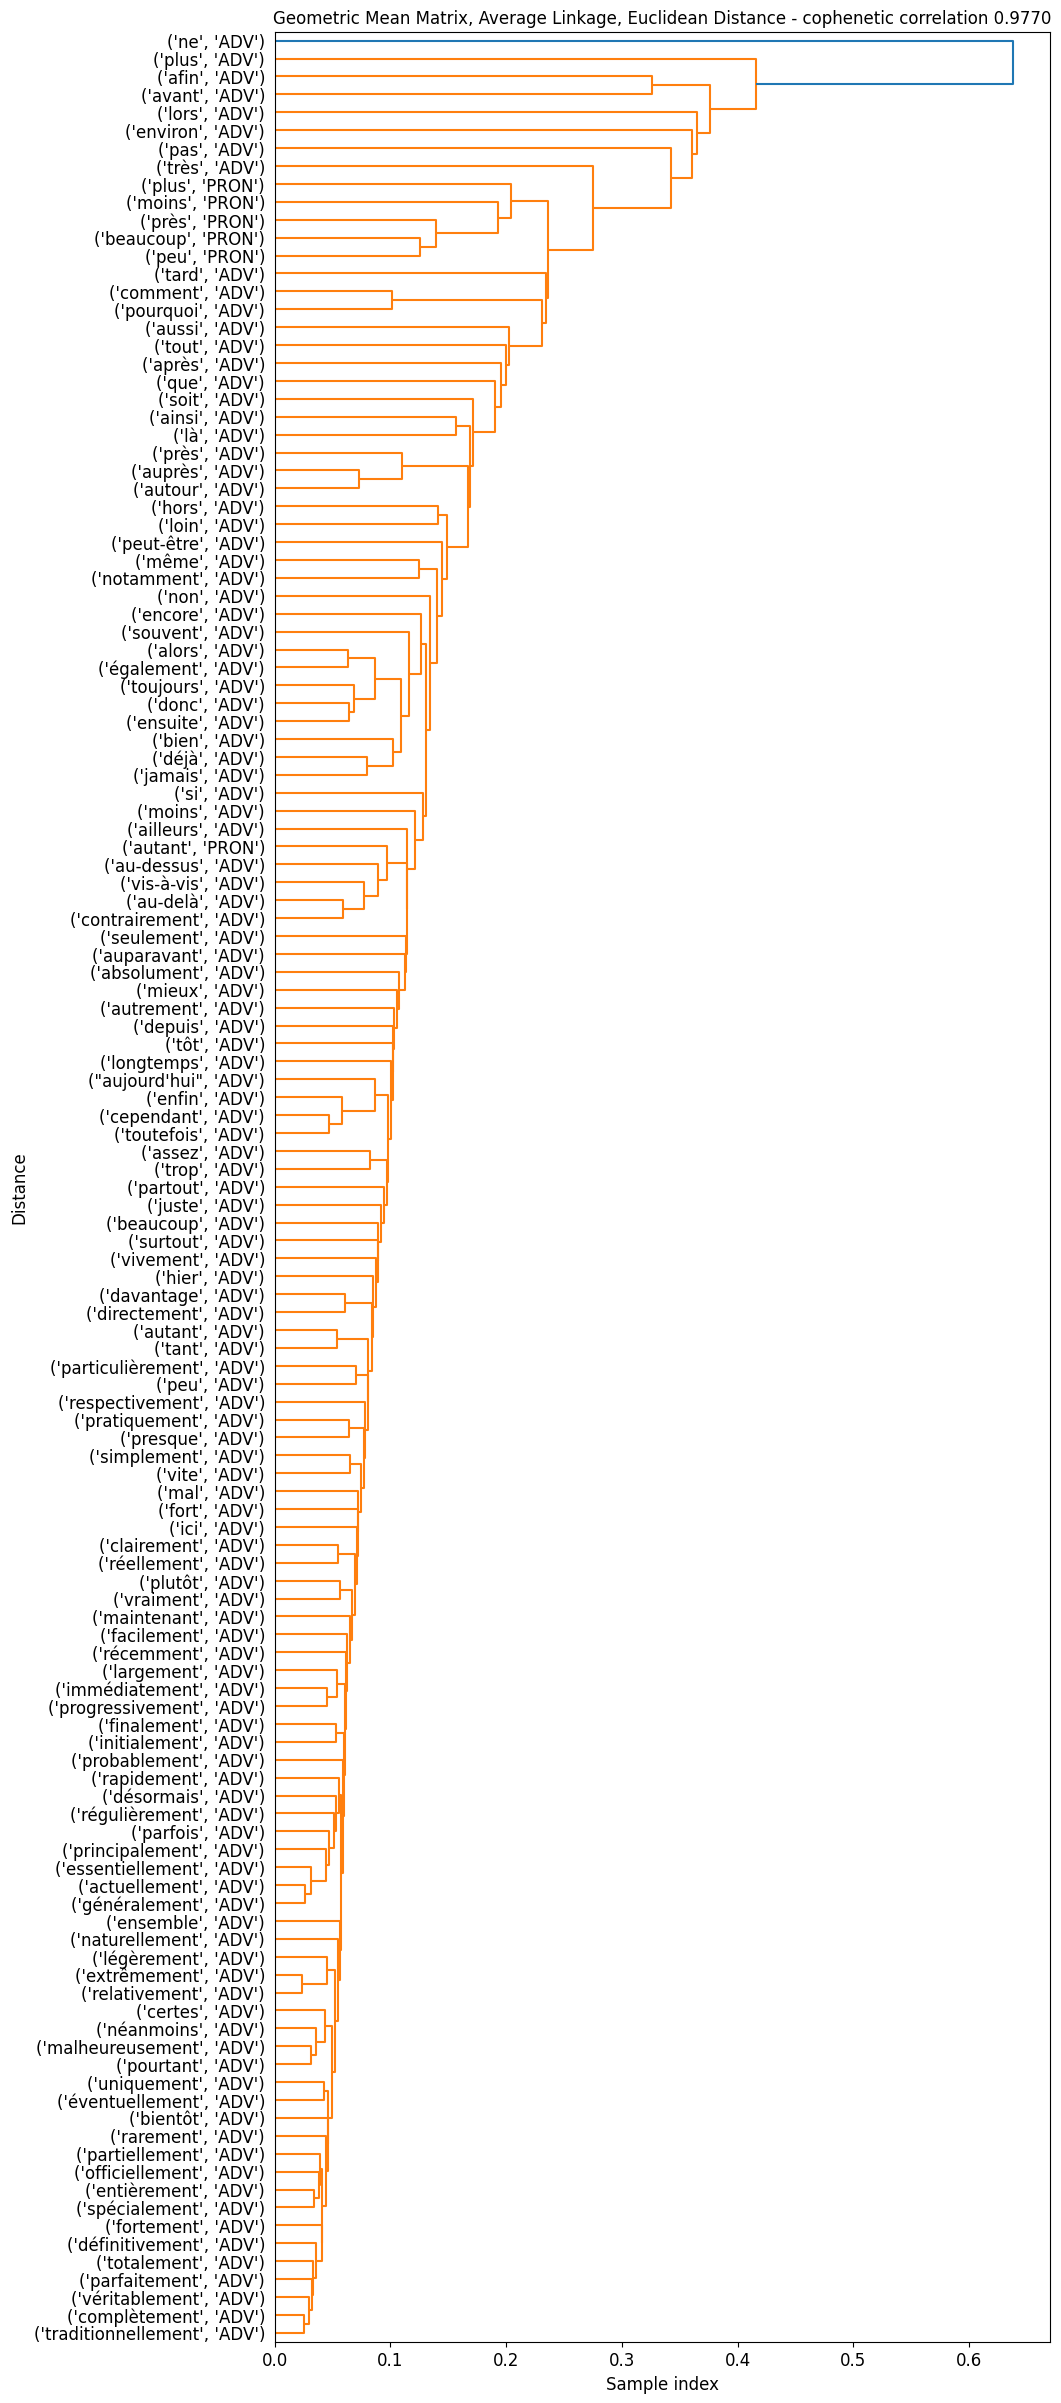

In [19]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

with open(f"geometric_mean_orig_dims.npy", 'rb') as f:
        X = np.load(f)
distance_matrix = pdist(X, metric="euclidean")
linked = linkage(
            distance_matrix, method="average", optimal_ordering=False
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Geometric Mean Matrix, Average Linkage, Euclidean Distance - cophenetic correlation 0.9770', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

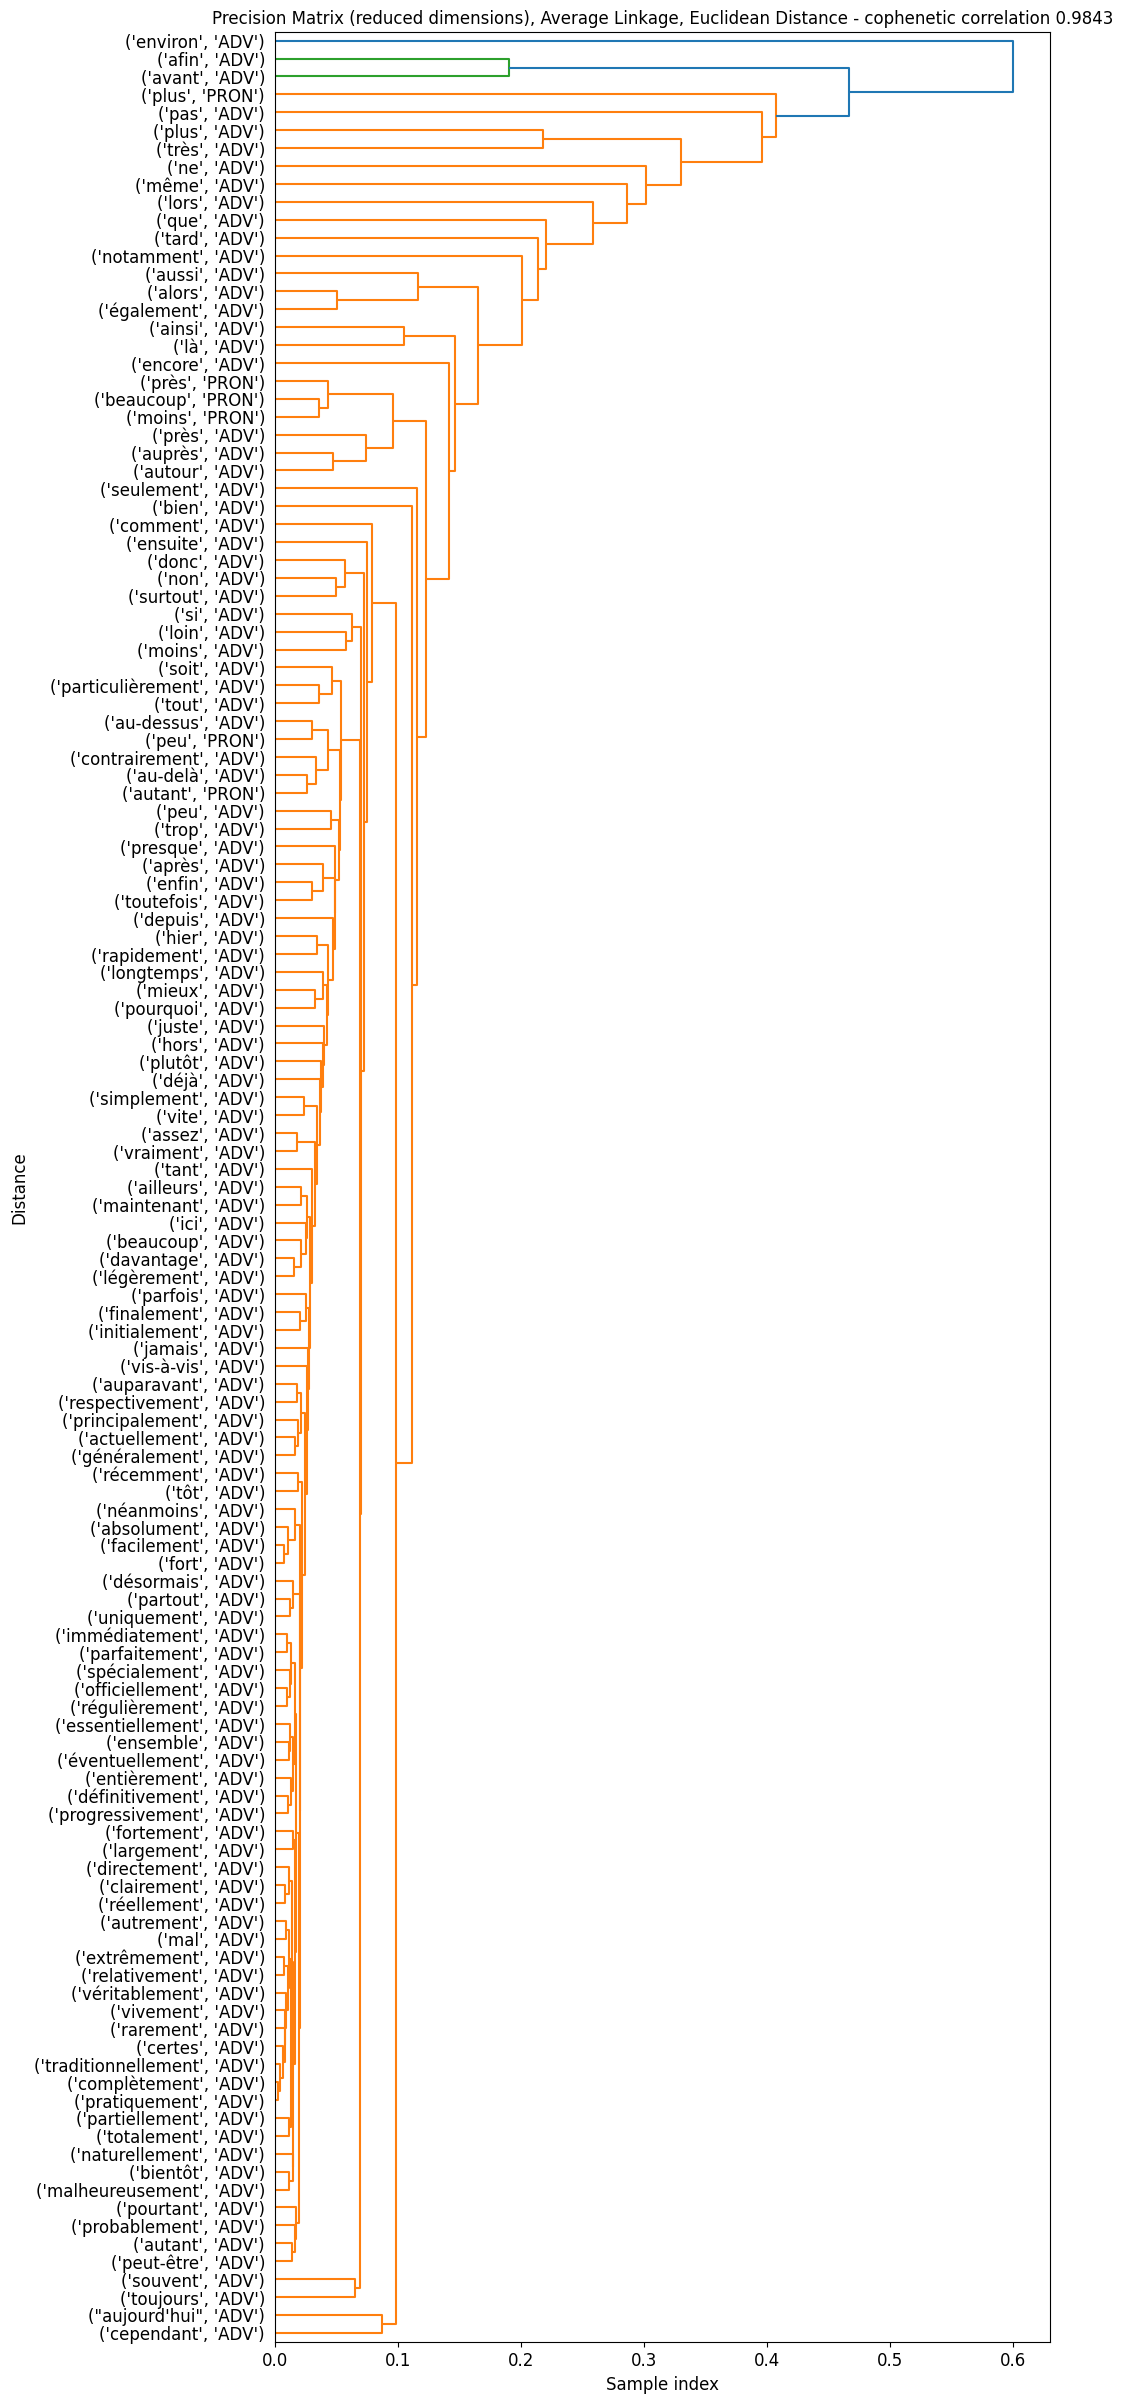

In [21]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

with open(f"precision_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
distance_matrix = pdist(X, metric="euclidean")
linked = linkage(
            distance_matrix, method="average", optimal_ordering=False
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Precision Matrix (reduced dimensions), Average Linkage, Euclidean Distance - cophenetic correlation 0.9843', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

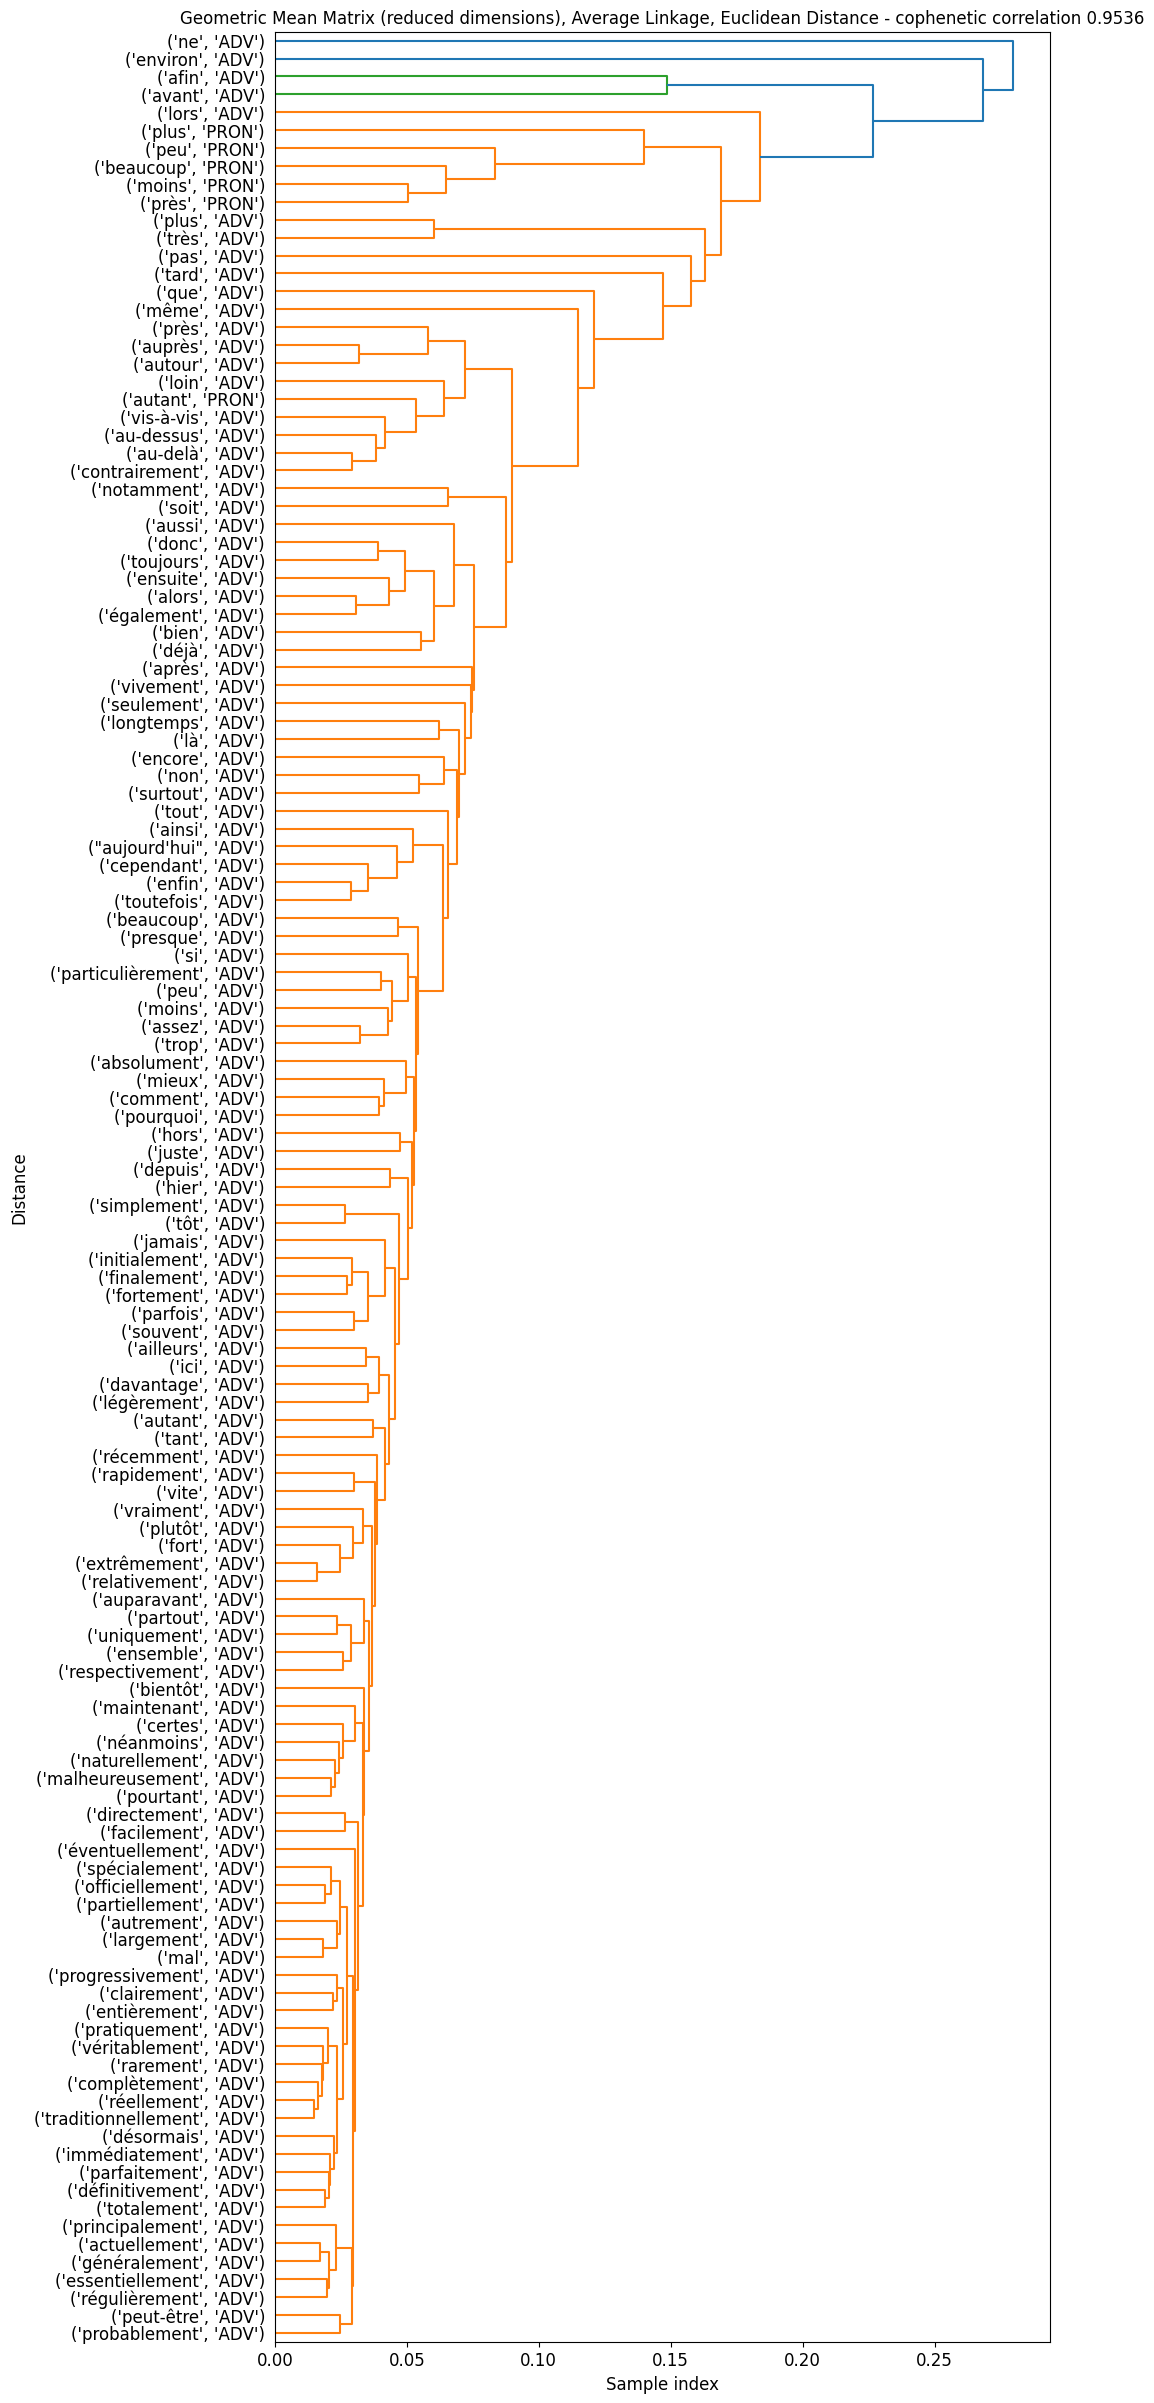

In [23]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

with open(f"geometric_mean_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
distance_matrix = pdist(X, metric="euclidean")
linked = linkage(
            distance_matrix, method="average", optimal_ordering=False
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Geometric Mean Matrix (reduced dimensions), Average Linkage, Euclidean Distance - cophenetic correlation 0.9536', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()